# Imports

In [1]:
import importlib
import sys
import torch
import pickle

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

# Data

### Load Data Files

In [2]:
# Path to your pickle file (saved with torch.save)
file_path_train = '../../../../encoded_data/test_philipp/domestic_declarations_all_5_train.pkl'
# Load the dataset using torch.load
dd_train_dataset = torch.load(file_path_train, weights_only=False)
# Check the type of the loaded dataset
print(type(dd_train_dataset))  # Should output something like <class 'event_log_loader.new_event_log_loader.EventLogDataset'>

# Path to your pickle file (saved with torch.save)
file_path_val = '../../../../encoded_data/test_philipp/domestic_declarations_all_5_val.pkl'
# Load the dataset using torch.load
dd_val_dataset = torch.load(file_path_val, weights_only=False)
# Check the type of the loaded dataset
print(type(dd_val_dataset))  # Should output something like <class 'event_log_loader.new_event_log_loader.EventLogDataset'>

<class 'event_log_loader.new_event_log_loader.EventLogDataset'>
<class 'event_log_loader.new_event_log_loader.EventLogDataset'>


### Train Data Insights

In [3]:
print(dd_train_dataset[:5])

((tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 1, 3, 7, 5],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 1, 3, 7, 5, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 1, 3, 7, 5, 2, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 1, 3, 7, 5, 2, 2, 2],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 9, 1, 3, 7, 5, 2, 2, 2, 2]]), tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 3],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 3, 3, 1, 1, 1, 1]]), tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 7, 8, 8],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 7, 8, 8, 4],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 7, 8, 8, 4, 4],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 1, 7, 8, 8, 4, 4, 4],
        [0, 0,

In [4]:
# DomesticDeclarations Dataset Categories, Features:

dd_all_categories = dd_train_dataset.all_categories

dd_all_categories_cat = dd_all_categories[0]
print(dd_all_categories_cat)

dd_all_categories_num = dd_all_categories[1]
print(dd_all_categories_num)

for i, cat in enumerate(dd_all_categories_cat):
     print(f"DomesticDeclarations (5) Categorical feature: {cat[0]}, Index position in categorical data list: {i}")
     print(f"DomesticDeclarations (5) Total Amount of Category labels: {cat[1]}")
print('\n')    
for i, num in enumerate(dd_all_categories_num):
     print(f"DomesticDeclarations (5) Numerical feature: {num[0]}, Index position in categorical data list: {i}")
     print(f"DomesticDeclarations (5) Amount Numerical: {num[1]}")

[('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})]
[('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})]
DomesticDeclarations (5) Categorical feature: Activity, Index position in categorical data list: 0
DomesticDeclarations (5) Total Amount of Category labels: 10
DomesticDeclarations (5) Categorical feature: Resource, Index position in categorical data list: 1
DomesticDeclarations (5) Total Amount of Category labels: 4
DomesticDeclarations (5) Categorical feature: Role, Index position in categorical data list: 2
DomesticDeclarations (5) Total Amount of Category labels: 9


DomesticDecl

### Input Features for Encoder and Decoder

In [5]:
# Create lists with name of Encoder features (input) and decoder features (input & output)

# Encoder features: all categorical and numerical features
enc_feat_cat = []
enc_feat_num = []
for cat in dd_all_categories_cat:
    enc_feat_cat.append(cat[0])
for num in dd_all_categories_num:
    enc_feat_num.append(num[0])
enc_feat = [enc_feat_cat, enc_feat_num]
print("Input features encoder: ", enc_feat)

# Decoder features: Activity, Resource for categorical; case_elapsed_time, event_elapsed_time for numerical
dec_feat_cat = ['Activity', 'Resource']
dec_feat_num = ['case_elapsed_time', 'event_elapsed_time']
dec_feat = [dec_feat_cat, dec_feat_num]
print("Features decoder: ", dec_feat)

Input features encoder:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Features decoder:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


In [6]:
# pickle the encoding data
import pickle

encoding_data = {"all_categories":dd_all_categories, "encoding_features": enc_feat, "decoding_features": dec_feat}

with open("encoding_data.pkl", "wb") as file:
    pickle.dump(encoding_data, file)

# Model

In [7]:
import model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model
importlib.reload(model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model)
from model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

# Prediction decoder output sequence length
seq_len_pred = 4

# Size hidden layer
hidden_size = 64

# Number of cells
num_layers = 2

# Fixed Dropout probability
dropout = 0.3

with open ("model_params_4layers.pkl", "wb") as f:
    params = {"data_set_categories":dd_all_categories,
                                             "enc_feat":enc_feat,
                                             "dec_feat":dec_feat,
                                             "seq_len_pred":seq_len_pred,
                                             "hidden_size":hidden_size,
                                             "num_layers":num_layers,
                                             "dropout":dropout}
    pickle.dump(params, f)

# Encoder Decoder model initialization
model = DropoutUncertaintyEncoderDecoderLSTM(data_set_categories=dd_all_categories,
                                             enc_feat=enc_feat,
                                             dec_feat=dec_feat,
                                             seq_len_pred=seq_len_pred,
                                             hidden_size=hidden_size,
                                             num_layers=num_layers,
                                             dropout=dropout)

Data set categories:  ([('Activity', 10, {'APPROVED': 1, 'EOS': 2, 'FINAL_APPROVED': 3, 'FOR_APPROVAL': 4, 'Payment Handled': 5, 'REJECTED': 6, 'Request Payment': 7, 'SAVED': 8, 'SUBMITTED': 9}), ('Resource', 4, {'EOS': 1, 'STAFF MEMBER': 2, 'SYSTEM': 3}), ('Role', 9, {'ADMINISTRATION': 1, 'BUDGET OWNER': 2, 'EMPLOYEE': 3, 'EOS': 4, 'MISSING': 5, 'PRE_APPROVER': 6, 'SUPERVISOR': 7, 'UNDEFINED': 8})], [('case_elapsed_time', 1, {}), ('event_elapsed_time', 1, {}), ('day_in_week', 1, {}), ('seconds_in_day', 1, {}), ('Amount', 1, {})])
Encoder input features:  [['Activity', 'Resource', 'Role'], ['case_elapsed_time', 'event_elapsed_time', 'day_in_week', 'seconds_in_day', 'Amount']]
Decoder input+output features:  [['Activity', 'Resource'], ['case_elapsed_time', 'event_elapsed_time']]


Sequence length of decoder output:  4


Cells hidden size:  64
Number of LSTM layer:  2
Dropout rate:  0.3


Encoder number of labels for each input feature (categorical, numerical):  [[10, 4, 9], [1, 1, 1, 1,

# Loss Object Creation

In [8]:
import loss.losses
importlib.reload(loss.losses)
from loss.losses import Loss

loss_obj = Loss()

# Training Configuration

In [9]:
import trainer.trainer
importlib.reload(trainer.trainer)
from trainer.trainer import Trainer
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(comment="Full_DomesticDeclarations_grad")

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Start learning rate
learning_rate = 1e-4

# Optimizer and Scheduler
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-8)

# Epochs
num_epochs = 35

# Batch size
batch_size = 128

# lambda for L2 (weight, bias, dropout) regularization: According to formula: 1/2N
regularization_term = 1e-4

# shuffle data
shuffle = True

# Teacher forcing: Smaller 0.5 more target events are used for next event prediction.
teacher_forcing_ratio = 0.8

optimize_values = {"regularization_term":regularization_term,
                   "optimizer":optimizer,
                   "scheduler": scheduler,
                   "epochs":num_epochs,
                   "mini_batches":batch_size,
                   "shuffle": shuffle,
                   "teacher_forcing_ratio":teacher_forcing_ratio,}

suffix_data_split_value = 4

# GradNorm parameter
use_gradnorm = True
gn_alpha = 1.5
gn_learning_rate = 1e-4

number_tasks = len(dec_feat[0]) + len(dec_feat[1])

gradNorm = {"use_gradnorm":use_gradnorm,
            "number_tasks": number_tasks,
            "gn_alpha":gn_alpha,
            "gn_learning_rate": gn_learning_rate}

trainer = Trainer(device=device,
                  model=model,
                  data_train=dd_train_dataset,
                  data_val=dd_val_dataset,
                  loss_obj=loss_obj,
                  log_normal_loss_num_feature = [],
                  optimize_values=optimize_values,
                  suffix_data_split_value=suffix_data_split_value,
                  writer=writer,
                  gradnorm_values=gradNorm,
                  save_model_n_th_epoch = 10,
                  saving_path = 'DomesticDeclarations_full_grad_norm_4layer_philipp_unchanged.pkl')

# Train the model:
train_attenuated_losses, val_losses, val_attenuated_losses = trainer.train_model()

Device:  cpu
Model:  DropoutUncertaintyEncoderDecoderLSTM(
  (embeddings_enc): ModuleList(
    (0): Embedding(10, 6)
    (1): Embedding(4, 3)
    (2): Embedding(9, 5)
  )
  (encoder): DropoutUncertaintyLSTMEncoder(
    (embeddings): ModuleList(
      (0): Embedding(10, 6)
      (1): Embedding(4, 3)
      (2): Embedding(9, 5)
    )
    (first_layer): DropoutUncertaintyLSTMCell(
      (Wi): Linear(in_features=19, out_features=64, bias=True)
      (Ui): Linear(in_features=64, out_features=64, bias=True)
      (Wf): Linear(in_features=19, out_features=64, bias=True)
      (Uf): Linear(in_features=64, out_features=64, bias=True)
      (Wc): Linear(in_features=19, out_features=64, bias=True)
      (Uc): Linear(in_features=64, out_features=64, bias=True)
      (Wo): Linear(in_features=19, out_features=64, bias=True)
      (Uo): Linear(in_features=64, out_features=64, bias=True)
    )
    (hidden_layers): ModuleList(
      (0): DropoutUncertaintyLSTMCell(
        (Wi): Linear(in_features=64, o

  0%|          | 0/35 [00:00<?, ?it/s]

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/35], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 3.6399
Validation: Avg Standard Validation Loss: 2.7444
Validation: Avg Attenuated Validation Loss: 1.5548
Validation Loss for Scheduler: 2.7444
Epoch [2/35], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: 0.6910
Validation: Avg Standard Validation Loss: 2.2565
Validation: Avg Attenuated Validation Loss: 0.1529
Validation Loss for Scheduler: 2.2565
Epoch [3/35], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: -0.8469
Validation: Avg Standard Validation Loss: 2.1004
Validation: Avg Attenuated Validation Loss: 0.3889
Validation Loss for Scheduler: 2.1004
Epoch [4/35], Learning Rate: 0.0001, Teacher forcing ratio: 0.8
Training: Avg Attenuated Training Loss: -1.5972
Validation: Avg Standard Validation Loss: 2.0484
Validation: Avg Attenuated Validation Loss: 1.4687
Validation Loss for Scheduler: 2.0484
Ep

# Training Visualization

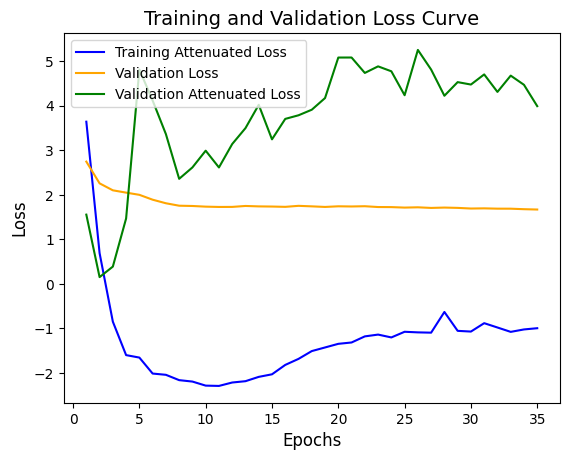

In [10]:
import matplotlib.pyplot as plt

# After training is finished, plot the loss curves
plt.plot(range(1, num_epochs+1), train_attenuated_losses, label='Training Attenuated Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='orange')
plt.plot(range(1, num_epochs+1), val_attenuated_losses, label='Validation Attenuated Loss', color='green')
# Labeling x and y axes
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# Adding title
plt.title('Training and Validation Loss Curve', fontsize=14)
# Adding legend
plt.legend()
# Show the plot
plt.show()

In [11]:
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../encoded_data/test_philipp/domestic_declarations_all_5_test.pkl'
# Load the dataset using torch.load
dd_test_dataset = torch.load(file_path_test, weights_only=False)
# Check the type of the loaded dataset
print(type(dd_test_dataset))  # Should output something like <class 'event_log_loader.new_event_log_loader.EventLogDataset'>

<class 'event_log_loader.new_event_log_loader.EventLogDataset'>
